# **Modelado de Sudoku como BILP  en Julia (JuMP + GLPK)**

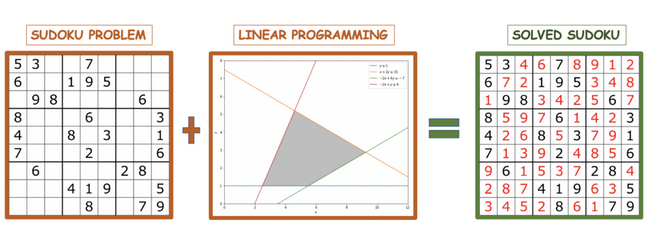



Un Sudoku de $9 \times 9$ es un problema de satisfacción de restricciones donde el objetivo es completar las celdas vacías respetando tres reglas críticas: cada número del $1$ al $9$ debe aparecer exactamente una vez en cada **fila**, cada **columna** y cada **subcuadrícula** de $3 \times 3$.

**IMPLEMENTACIÓN EN JULIA**

In [ ]:
using Pkg
if !haskey(Pkg.dependencies(), Base.UUID("4076af6c-e464-5606-a7c1-127c4b4c7460"))
    Pkg.add("JuMP")
end
if !haskey(Pkg.dependencies(), Base.UUID("60bf3e54-4046-11e9-197e-9f88c87a1e29"))
    Pkg.add("GLPK")
end

using JuMP
using GLPK
using Printf

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed CodecBzip2 ───────── v0.8.5
   Installed MutableArithmetics ─ v1.8.0
   Installed MathOptInterface ─── v1.51.1
   Installed JuMP ─────────────── v1.30.1
    Updating `~/.julia/environments/v1.12/Project.toml`
  [4076af6c] + JuMP v1.30.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [523fee87] + CodecBzip2 v0.8.5
  [4076af6c] + JuMP v1.30.1
  [b8f27783] + MathOptInterface v1.51.1
  [d8a4904e] + MutableArithmetics v1.8.0
Precompiling packages...
   2867.2 ms  ✓ CodecBzip2
  11586.2 ms  ✓ MutableArithmetics
  87146.5 ms  ✓ MathOptInterface
  59999.6 ms  ✓ JuMP
  4 dependencies successfully precompiled in 164 seconds. 480 already precompiled.
   Resolving package versions...
   Installed GLPK ───── v1.2.1
   Installed GLPK_jll ─ v5.0.1+1
  Installing 1 artifacts
   Installed artifact GLPK                     3.1 MiB
    Updating `~/.julia/environments/v1.12/Project.toml`
 

# Banco de pruebas

 El banco de pruebas se compone de un total de **40 matrices** de Sudoku (10 por cada nivel de dificultad), las cuales fueron transcritas directamente de un libro con problemas lógicos combinatorios, asegurando así un marco de evaluación estandarizado y riguroso para el optimizador.

In [ ]:
#BANCO DE PRUEBAS
# BANCO DE PRUEBAS COMPLETO (40 MATRICES: 10 POR NIVEL)

function banco_de_pruebas()
    banco = Dict(
        " Fácil" => Vector{Matrix{Int}}(),
        " Moderado" => Vector{Matrix{Int}}(),
        " Difícil" => Vector{Matrix{Int}}(),
        " Extremadamente Difícil" => Vector{Matrix{Int}}()
    )

    # NIVEL FÁCIL
    push!(banco[" Fácil"], [
        5 3 0 0 7 0 0 0 0; 6 0 0 1 9 5 0 0 0; 0 9 8 0 0 0 0 6 0;
        8 0 0 0 6 0 0 0 3; 4 0 0 8 0 3 0 0 1; 7 0 0 0 2 0 0 0 6;
        0 6 0 0 0 0 2 8 0; 0 0 0 4 1 9 0 0 5; 0 0 0 0 8 0 0 7 9
    ])
    push!(banco[" Fácil"], [
        0 0 0 2 6 0 7 0 1; 6 8 0 0 7 0 0 9 0; 1 9 0 0 0 4 5 0 0;
        8 2 0 1 0 0 0 4 0; 0 0 4 6 0 2 9 0 0; 0 5 0 0 0 3 0 2 8;
        0 0 9 3 0 0 0 7 4; 0 4 0 0 5 0 0 3 6; 7 0 3 0 1 8 0 0 0
    ])
    push!(banco[" Fácil"], [
        0 0 0 2 6 0 7 0 1; 6 8 0 0 7 0 0 9 0; 1 9 0 0 0 4 5 0 0;
        8 2 0 1 0 0 0 4 0; 0 0 4 6 0 2 9 0 0; 0 5 0 0 0 3 0 2 8;
        0 0 9 3 0 0 0 7 4; 0 4 0 0 5 0 0 3 6; 7 0 3 0 1 8 0 0 0
    ])
    push!(banco[" Fácil"], [
        0 4 0 0 2 0 0 0 0; 5 0 0 7 0 0 0 0 0; 7 0 0 0 4 0 3 0 2;
        0 7 1 6 3 0 0 0 0; 0 0 9 0 7 4 0 3 6; 6 3 0 2 5 0 0 0 0;
        1 8 0 0 0 0 0 9 3; 4 0 7 0 0 8 5 6 1; 0 0 3 0 0 2 8 7 0
    ])
    push!(banco[" Fácil"], [
        0 0 0 1 9 0 0 6 0; 4 0 0 0 0 2 0 7 0; 0 2 0 6 0 0 3 8 5;
        0 0 6 0 2 0 0 0 0; 0 0 0 0 0 3 1 2 6; 0 0 3 0 0 0 5 9 7;
        8 0 0 0 0 1 0 0 9; 0 4 0 7 5 9 6 0 0; 0 0 9 0 4 8 7 1 0
    ])
    push!(banco[" Fácil"], [
        0 0 0 6 2 4 0 7 3; 4 0 0 0 3 0 0 5 6; 0 7 0 8 0 0 0 0 0;
        0 0 0 0 6 0 3 0 2; 8 0 9 7 4 0 6 0 0; 0 0 1 0 8 3 7 0 0;
        3 9 0 0 0 0 1 0 8; 0 0 7 0 0 0 2 4 0; 0 4 0 0 9 8 0 0 0
    ])
    push!(banco[" Fácil"], [ ###
        9 6 1 0 4 3 0 0 2; 7 0 3 0 8 5 9 4 1; 0 4 5 9 2 1 0 0 0;
        3 9 0 1 0 0 0 0 5; 1 0 4 0 9 2 3 6 8; 5 0 2 4 3 0 0 0 7;
        4 3 7 8 0 9 2 0 0; 0 1 0 2 5 0 8 3 0; 0 5 8 3 0 4 7 0 0
    ])
    push!(banco[" Fácil"], [
        0 0 6 7 0 2 8 9 5; 0 0 0 5 0 0 0 6 3; 5 0 0 0 3 0 2 0 7;
        0 6 9 0 0 0 0 4 0; 3 0 8 0 0 0 0 7 6; 0 1 0 0 5 8 0 3 0;
        6 0 0 2 0 7 0 0 0; 0 4 0 0 0 3 6 0 0; 0 2 3 4 0 5 0 8 1
    ])
    # Fácil 9
    push!(banco[" Fácil"], [
        4 0 1 0 7 0 2 3 0; 0 3 0 5 2 0 4 6 1; 0 8 0 0 3 0 5 0 7;
        0 0 0 0 0 0 9 0 0; 0 6 7 1 0 2 3 0 0; 0 4 2 9 0 0 0 0 6;
        6 7 0 0 0 3 0 0 0; 0 2 0 7 4 5 0 0 0; 5 0 0 0 0 0 7 4 0
    ])
    push!(banco[" Fácil"], [
        3 0 0 0 8 0 4 0 0; 0 0 8 0 0 4 0 1 0; 4 7 0 0 9 0 0 0 0;
        0 5 0 8 2 1 9 0 0; 0 0 9 0 0 7 3 0 0; 0 2 4 0 3 9 7 0 0;
        0 1 0 0 4 0 0 7 5; 0 0 0 0 5 0 1 2 3; 0 0 7 0 0 6 8 0 4
    ])

    # NIVEL MODERADO (1 a 10)
    push!(banco[" Moderado"], [
        0 3 0 1 0 0 9 7 0; 0 0 0 0 4 0 3 0 0; 0 0 2 8 0 0 0 4 0;
        3 0 0 0 0 5 0 0 0; 0 8 0 7 0 0 0 0 5; 0 0 0 0 1 0 8 9 4;
        9 0 0 0 0 0 0 6 0; 8 0 0 0 0 0 0 0 2; 1 4 0 0 0 0 0 0 0
    ])
    push!(banco[" Moderado"], [
        0 8 0 0 0 0 0 5 6; 0 0 0 9 0 0 0 0 8; 0 6 0 8 4 0 7 2 0;
        0 0 0 0 7 9 0 0 0; 0 7 6 5 0 0 0 0 0; 0 4 0 0 0 0 5 0 1;
        1 0 0 0 6 0 0 0 0; 3 5 0 0 0 0 0 0 0; 0 0 0 0 2 7 0 3 0
    ])
    push!(banco[" Moderado"], [
        0 0 0 0 7 3 0 4 0; 0 3 2 5 0 0 0 7 0; 0 0 0 0 9 0 0 0 0;
        0 0 8 1 0 0 0 6 5; 9 0 1 0 0 0 0 0 0; 0 4 0 0 3 0 0 0 0;
        0 9 0 0 0 4 6 0 0; 0 2 0 0 0 1 0 8 0; 0 0 0 9 0 8 0 0 0
    ])
    push!(banco[" Moderado"], [
        0 0 0 0 0 6 0 5 2; 9 0 0 0 0 1 0 0 7; 0 0 0 8 0 0 0 0 0;
        0 2 4 0 0 0 8 0 0; 0 0 1 0 5 0 0 7 0; 0 9 0 4 0 0 0 0 5;
        0 0 0 0 6 5 0 1 0; 0 0 0 0 0 2 4 3 0; 7 0 0 0 8 0 0 0 0
    ])
    push!(banco[" Moderado"], [
        1 6 0 0 0 0 0 0 0; 0 0 0 0 0 0 0 5 0; 8 3 0 0 1 4 0 2 0;
        0 0 0 0 7 0 9 0 4; 0 0 0 0 0 0 0 3 5; 3 0 0 0 0 6 0 0 0;
        0 0 0 0 0 8 0 9 0; 0 0 7 0 0 2 6 0 0; 6 0 0 0 0 9 0 1 3
    ])
    push!(banco[" Moderado"], [####
        0 0 0 9 0 3 0 4 0; 0 3 6 0 0 0 0 0 2; 0 0 0 0 4 0 0 0 0;
        0 0 9 7 0 2 0 0 0; 0 7 0 0 0 0 0 9 0; 0 0 0 1 0 8 6 0 0;
        0 0 0 0 7 0 0 0 0; 9 0 0 0 0 0 4 7 0; 0 4 0 2 0 9 0 0 0
    ])
    push!(banco[" Moderado"], [
        0 0 0 9 0 3 0 4 0; 0 3 6 0 0 0 0 0 2; 0 0 0 0 4 0 0 0 0;
        0 0 9 7 0 2 0 0 0; 0 7 0 0 0 0 0 9 0; 0 0 0 1 0 8 6 0 0;
        0 0 0 0 7 0 0 0 0; 9 0 0 0 0 0 4 7 0; 0 4 0 2 0 9 0 0 0
    ])
    push!(banco[" Moderado"], [
        3 0 0 0 4 0 0 1 0; 0 0 0 0 0 6 0 0 7; 0 0 4 0 0 0 5 0 0;
        0 0 8 0 0 0 9 0 0; 0 4 0 0 0 0 0 6 0; 0 0 3 0 0 0 8 0 0;
        0 0 6 0 0 0 4 0 0; 8 0 0 5 0 0 0 0 0; 0 2 0 0 7 0 0 0 9
    ])
    push!(banco[" Moderado"], [
        0 0 0 0 0 4 0 7 0; 0 2 0 8 0 0 0 0 5; 0 0 6 0 9 0 0 0 0;
        0 0 0 0 0 0 0 9 0; 0 0 4 0 6 0 2 0 0; 0 8 0 0 0 0 0 0 0;
        0 0 0 0 3 0 6 0 0; 9 0 0 0 0 7 0 4 0; 0 7 0 4 0 0 0 0 0
    ])
    push!(banco[" Moderado"], [
        0 6 0 0 4 0 8 0 0; 0 0 0 0 0 6 0 0 4; 0 0 5 0 0 0 9 0 0;
        0 0 4 0 0 0 5 0 0; 0 7 0 0 0 0 0 2 0; 0 0 9 0 0 0 4 0 0;
        0 0 6 0 0 0 7 0 0; 5 0 0 2 0 0 0 0 0; 0 0 8 0 7 0 0 9 0
    ])

    # NIVEL DIFÍCIL (1 a 10)
    push!(banco[" Difícil"], [
        0 0 0 0 0 8 0 0 6; 4 0 2 9 6 0 8 0 0; 6 7 0 0 0 0 0 4 0;
        7 0 0 5 0 0 0 9 0; 0 4 0 0 0 3 0 0 7; 0 3 0 8 1 0 0 6 0;
        0 0 5 0 0 0 0 0 2; 0 0 4 0 0 0 0 0 0; 3 0 0 0 0 0 0 0 1
    ])
    push!(banco[" Difícil"], [
        0 9 0 0 0 7 0 0 0; 2 0 0 0 0 0 9 0 8; 0 0 6 0 4 0 2 1 0;
        0 0 0 0 1 0 7 5 0; 0 0 0 0 3 9 0 0 0; 0 0 0 2 0 8 6 0 0;
        8 0 4 0 0 0 0 7 0; 0 0 9 0 8 0 0 0 0; 0 6 3 0 0 0 1 0 0
    ])
    push!(banco[" Difícil"], [
        0 3 4 2 0 0 0 0 0; 0 0 0 0 0 0 0 0 8; 8 0 0 1 0 0 0 0 3;
        0 0 2 0 4 5 0 0 1; 0 1 0 0 0 0 0 0 0; 0 0 7 3 0 2 0 0 4;
        1 0 6 0 0 0 4 0 0; 0 0 3 0 0 0 0 8 2; 5 0 0 0 0 4 9 0 7
    ])
    push!(banco[" Difícil"], [
        0 0 0 5 0 0 0 4 0; 0 0 0 3 0 9 0 0 8; 0 0 6 0 0 0 2 0 0;
        7 9 0 0 0 0 0 3 1; 1 5 0 0 0 7 0 0 0; 0 0 0 0 0 0 5 0 0;
        6 0 7 0 1 0 0 0 0; 0 0 0 0 7 4 0 6 0; 3 0 0 0 0 2 0 7 0
    ])
    push!(banco[" Difícil"], [###
        0 7 0 2 0 6 0 8 0; 0 0 1 0 0 5 0 6 0; 4 0 0 0 0 0 3 0 0;
        0 0 0 0 0 9 0 0 0; 0 0 0 8 0 0 0 0 0; 1 6 8 0 0 0 0 7 0;
        5 0 0 0 9 2 0 4 0; 2 0 0 7 0 8 9 0 6; 0 0 0 4 0 0 7 0 0
    ])
    push!(banco[" Difícil"], [
        0 0 0 0 0 2 5 0 0; 0 0 0 0 6 0 0 0 9; 7 0 0 9 4 0 0 6 0;
        0 0 8 1 9 0 0 0 0; 0 0 5 0 0 0 7 0 0; 0 0 0 0 2 7 8 0 0;
        0 5 0 0 1 9 0 0 6; 6 0 0 0 7 0 0 0 0; 0 0 9 2 0 0 0 0 0
    ])
    push!(banco[" Difícil"], [
        0 0 0 0 0 0 4 0 9; 0 0 0 5 0 0 0 0 0; 0 0 7 0 4 9 0 0 5;
        0 0 4 0 0 6 8 0 0; 2 0 0 0 8 0 0 0 6; 0 0 6 7 0 0 3 0 0;
        9 0 0 6 3 0 2 0 0; 0 0 0 0 0 4 0 0 0; 6 0 5 0 0 0 0 0 0
    ])
    push!(banco[" Difícil"], [
        9 0 0 2 0 7 0 0 0; 0 0 0 0 8 0 0 0 1; 0 3 0 0 0 0 9 0 0;
        0 0 9 0 5 0 0 7 0; 7 5 0 0 0 0 0 6 8; 0 6 0 0 1 0 4 0 0;
        0 0 8 0 0 0 0 2 0; 4 0 0 0 6 0 0 0 0; 0 0 0 8 0 4 0 0 5
    ])
    push!(banco[" Difícil"], [
        0 0 0 0 0 0 6 8 0; 9 0 0 0 8 0 0 3 0; 0 8 0 6 0 3 0 0 0;
        0 9 0 0 0 0 0 2 0; 0 0 5 0 0 0 3 0 0; 0 2 0 0 0 0 0 4 0;
        0 0 0 9 0 7 0 6 0; 0 6 0 0 2 0 0 0 4; 0 7 8 0 0 0 0 0 0
    ])
    push!(banco[" Difícil"], [
        0 0 0 0 5 0 0 6 2; 0 0 0 2 0 7 0 0 0; 0 0 2 0 0 0 9 0 0;
        0 0 0 0 0 9 0 0 0; 0 0 5 0 7 0 3 0 0; 0 0 0 8 0 0 0 0 0;
        0 0 8 0 0 0 4 0 0; 0 0 0 7 0 3 0 0 0; 6 3 0 0 8 0 0 0 0
    ])

    # NIVEL EXTREMADAMENTE DIFÍCIL (1 a 10)
    push!(banco[" Extremadamente Difícil"], [
        0 4 0 0 0 0 2 0 0; 0 1 7 5 0 0 0 0 0; 0 0 0 0 3 0 0 0 0;
        4 0 0 0 0 8 0 9 3; 6 0 0 0 0 0 0 0 4; 0 3 0 0 7 1 0 8 0;
        8 0 0 0 9 0 0 3 0; 0 5 0 0 0 0 0 7 0; 0 0 0 0 2 0 6 0 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 6 0 0 5 0 7 0 2; 0 0 0 0 0 7 3 5 0; 8 0 0 0 2 0 0 0 0;
        2 0 0 6 0 0 0 4 0; 9 0 7 0 0 2 0 0 0; 6 0 0 1 8 0 0 0 0;
        0 0 9 0 0 0 0 0 0; 0 0 0 0 0 0 4 2 0; 4 0 0 0 0 0 0 1 9
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 0 7 0 0 0 0 1 0; 0 5 0 4 0 0 0 0 7; 8 4 0 0 0 0 0 0 6;
        0 0 2 5 0 3 0 0 0; 0 9 0 0 0 0 2 0 0; 3 7 1 0 0 0 0 5 0;
        7 0 0 0 0 0 0 0 0; 0 6 0 0 0 4 0 0 8; 0 2 4 0 0 8 0 9 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 0 4 0 0 0 5 8 0; 0 8 0 6 0 0 0 0 0; 0 3 0 0 0 5 0 0 9;
        0 0 0 0 0 0 7 0 0; 0 0 0 3 0 0 0 0 0; 0 9 0 0 0 7 0 0 4;
        5 0 0 0 0 0 0 7 0; 0 0 0 8 0 4 0 5 0; 0 1 0 0 0 0 8 0 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 0 8 0 0 0 0 4 0; 0 0 0 5 0 9 0 0 0; 6 0 0 0 0 0 7 0 0;
        0 0 0 0 7 0 0 0 2; 0 0 4 0 0 0 6 0 0; 7 0 0 0 2 0 0 0 0;
        0 0 1 0 0 0 0 0 8; 0 0 0 8 0 4 0 0 0; 0 6 0 0 0 0 5 0 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 0 0 0 8 0 0 0 5; 0 6 0 0 0 0 0 7 0; 0 0 5 0 0 3 0 0 0;
        0 0 0 4 0 0 0 8 0; 0 0 2 0 0 0 5 0 0; 0 8 0 0 0 7 0 0 0;
        0 0 0 7 0 0 3 0 0; 0 1 0 0 0 0 0 5 0; 7 0 0 0 4 0 0 0 0
    ])
    push!(banco[" Extremadamente Difícil"], [###
        0 0 0 8 0 1 0 3 4; 0 0 0 0 0 0 0 0 0; 5 0 0 0 9 0 8 1 0;
        0 0 0 0 4 8 0 0 0; 9 0 2 7 0 0 0 0 0; 7 6 0 0 0 9 3 0 0;
        0 0 0 0 2 0 0 4 0; 4 0 0 0 3 7 9 0 0; 0 0 6 0 0 0 0 2 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 0 0 8 0 1 0 3 4; 0 0 0 0 0 0 0 0 0; 5 0 0 0 9 0 8 1 0;
        0 0 0 0 4 8 0 0 0; 9 0 2 7 0 0 0 0 0; 7 6 0 0 0 9 3 0 0;
        0 0 0 0 2 0 0 4 0; 4 0 0 0 3 7 9 0 0; 0 0 6 0 0 0 0 2 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        0 0 0 6 0 0 0 7 2; 0 8 4 0 9 0 0 0 6; 0 5 0 0 0 2 8 0 1;
        0 0 0 0 0 0 0 0 0; 0 0 0 3 1 0 5 0 0; 1 0 0 0 7 0 0 0 0;
        0 1 0 0 0 0 0 2 0; 3 0 9 5 4 0 0 0 0; 6 0 5 0 0 0 0 0 0
    ])
    push!(banco[" Extremadamente Difícil"], [
        3 0 0 0 0 2 0 0 5; 0 0 0 0 5 0 4 0 0; 0 0 9 0 8 0 1 0 2;
        0 0 3 0 0 0 0 7 0; 0 0 4 6 0 0 0 0 0; 0 8 0 0 0 7 2 9 0;
        0 3 0 5 4 0 0 1 0; 0 0 0 0 0 1 6 0 0; 0 0 0 0 9 0 0 0 0
    ])

    return banco
end

banco_de_pruebas (generic function with 1 method)

# **Formulación del Problema (BILP)**


Restricciones del Sudoku

* Cada celda debe rellenarse con un único valor entre 1 y 9.

*  Cada fila debe contener cada número del 1 al 9 exactamente una vez.

*  Cada columna debe contener cada número del 1 al 9 exactamente una vez.

*  Cada región de 3x3 (subcuadrícula), comenzando desde la esquina superior izquierda, debe contener cada número del 1 al 9 exactamente una vez.

In [ ]:
#FUNCIÓN DE MODELADO EN JULIA (Formato BILP para GLPK)
function resolver_sudoku_julia(puzzle)
    sudoku = Model(GLPK.Optimizer)
    set_optimizer_attribute(sudoku, "msg_lev", GLPK.GLP_MSG_OFF)

    @variable(sudoku, x[i=1:9, j=1:9, k=1:9], Bin)

    for i=1:9, j=1:9
        @constraint(sudoku, sum(x[i,j,k] for k in 1:9) == 1)
    end

    for ind=1:9, k=1:9
        @constraint(sudoku, sum(x[ind,j,k] for j in 1:9) == 1)
        @constraint(sudoku, sum(x[i,ind,k] for i in 1:9) == 1)
    end

    for i=1:3:7, j=1:3:7, k=1:9
        @constraint(sudoku, sum(x[r,c,k] for r in i:i+2, c in j:j+2) == 1)
    end

    for i=1:9, j=1:9
        if puzzle[i,j] != 0
            @constraint(sudoku, x[i,j,puzzle[i,j]] == 1)
        end
    end

    optimize!(sudoku)
    return termination_status(sudoku)
end

resolver_sudoku_julia (generic function with 1 method)



# SIMULACIÓN Y MEDICIÓN

* **Calentamiento previo:** Corre un Sudoku de prueba antes de medir para que Julia compile el código a lenguaje de máquina. Así, ese tiempo de carga inicial no te ensucia los promedios reales.

* **Cronómetro preciso `(time_ns)`:** Mide la velocidad en nanosegundos (y luego la pasa a segundos). Esto se hace porque Julia es tan rápido que un cronómetro común en milisegundos te marcaría 0.

* **Promedios y reporte**: Pasa nivel por nivel, calcula cuánto tardó cada matriz en resolverse y te arma la tablita final limpia con los promedios para copiar y pegar en el informe.



In [ ]:
banco_pruebas = banco_de_pruebas()

orden_niveles = [" Fácil", " Moderado", " Difícil", " Extremadamente Difícil"]
promedios = Dict{String, Float64}()
tiempos_totales_por_nivel = Dict{String, Vector{Float64}}() # Initialize the new dictionary

# Calentamiento obligatorio para compilar funciones antes de cronometrar
resolver_sudoku_julia(banco_pruebas[" Fácil"][1])

for nivel in orden_niveles
    instancias = banco_pruebas[nivel]
    tiempos_nivel = Float64[]

    for (idx, sudoku_instancia) in enumerate(instancias)
        t_inicio = time_ns()

        # 1. Tu función ahora debe devolver el estado del solver
        status = resolver_sudoku_julia(sudoku_instancia)

        t_fin = time_ns()

        # 2. Validamos si el estado es el equivalente a "Optimal" en Julia
        # MO_I es MathOptInterface, el motor que maneja JuMP por detrás
        if status == JuMP.MOI.OPTIMAL
            tiempo_ejecucion = (t_fin - t_inicio) / 1e9
            push!(tiempos_nivel, tiempo_ejecucion)
        else
            println("Advertencia: El Sudoku $idx del nivel $nivel NO se pudo resolver. Estado: $status")
        end
    end
    tiempos_totales_por_nivel[nivel] = tiempos_nivel # Store the list of times for each level

    # Evita división por cero si un nivel se deja vacío o no hubo soluciones óptimas
    num_resueltos = length(tiempos_nivel)
    promedios[nivel] = num_resueltos > 0 ? sum(tiempos_nivel) / num_resueltos : 0.0
end


#REPORTE FINAL
println(" ")
println("RESUMEN FINAL DE TIEMPOS PROMEDIO")
for nivel in orden_niveles
    @printf("Nivel %-22s | Tiempo Promedio: %.6f seg\n", nivel, promedios[nivel])
end

 
RESUMEN FINAL DE TIEMPOS PROMEDIO
Nivel  Fácil                 | Tiempo Promedio: 0.020095 seg
Nivel  Moderado              | Tiempo Promedio: 0.054036 seg
Nivel  Difícil               | Tiempo Promedio: 0.052435 seg
Nivel  Extremadamente Difícil | Tiempo Promedio: 0.052753 seg


In [ ]:
# Guardamos los tiempos en un texto, para comparar con python
ruta_drive = "/content/tiempos_julia.txt"

open(ruta_drive, "w") do io
    for nivel in orden_niveles
        println(io, "$nivel:", join(tiempos_totales_por_nivel[nivel], ","))
    end
end

# **SUDOKU DIAGONAL**

Restricciones diagonales

* Cada diagonal debe contener cada número del 1 al 9 exactamente una vez.

## Simulación

In [ ]:
#FUNCIÓN DE MODELADO EN JULIA (Variante Sudoku-X)
function resolver_sudoku_diagonal(puzzle)
    sudoku = Model(GLPK.Optimizer)
    set_optimizer_attribute(sudoku, "msg_lev", GLPK.GLP_MSG_OFF)

    @variable(sudoku, x[i=1:9, j=1:9, k=1:9], Bin)

    # Restricción 1: Un valor por celda
    for i=1:9, j=1:9
        @constraint(sudoku, sum(x[i,j,k] for k in 1:9) == 1)
    end

    # Restricción 2 y 3: Filas y Columnas
    for ind=1:9, k=1:9
        @constraint(sudoku, sum(x[ind,j,k] for j in 1:9) == 1)
        @constraint(sudoku, sum(x[i,ind,k] for i in 1:9) == 1)
    end

    # Restricción 4: Bloques 3x3
    for i=1:3:7, j=1:3:7, k=1:9
        @constraint(sudoku, sum(x[r,c,k] for r in i:i+2, c in j:j+2) == 1)
    end

    # Restricción 5: REGLA DE LAS DIAGONALES (Sudoku-X)
    for k=1:9
        @constraint(sudoku, sum(x[i, i, k] for i in 1:9) == 1)         # Diag. Principal (\)
        @constraint(sudoku, sum(x[i, 10 - i, k] for i in 1:9) == 1)    # Diag. Secundaria (/)
    end

    # Restricción 6: Cargar pistas fijas
    for i=1:9, j=1:9
        if puzzle[i,j] != 0
            @constraint(sudoku, x[i,j,puzzle[i,j]] == 1)
        end
    end

    optimize!(sudoku)
    return termination_status(sudoku)
end

resolver_sudoku_diagonal (generic function with 1 method)

In [ ]:
diagonal_sudoku = [
    0 3 0 2 7 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    8 0 0 0 0 0 0 0 0;
    5 1 0 0 0 0 0 8 4;
    4 0 0 5 9 0 0 7 0;
    2 9 0 0 0 0 0 1 0;
    0 0 0 0 0 0 1 0 5;
    0 0 6 3 0 8 0 0 7;
    0 0 0 0 0 0 3 0 0
]
resolver_sudoku_diagonal(diagonal_sudoku)

tiempos = Float64[]

for intento in 1:10
    # Medición de alta precisión
    t_inicio = time_ns()

    # Ejecutamos pasando la matriz y capturamos el estado de JuMP
    status = resolver_sudoku_diagonal(diagonal_sudoku)

    t_fin = time_ns()

    if status == MOI.OPTIMAL
        tiempo_ejecucion = (t_fin - t_inicio) / 1e9
        push!(tiempos, tiempo_ejecucion)
        @printf("Corrida %02d: exitosa en %.6f seg\n", intento, tiempo_ejecucion)
    else
        println("Corrida $intento: No se pudo resolver. Estado: $status")
    end
end


if length(tiempos) > 0
    tiempo_total = sum(tiempos)
    tiempo_promedio = tiempo_total / length(tiempos)

    @printf("\n ")
    @printf("Tiempo Promedio:     %.6f segundos\n", tiempo_promedio)
else
    println("No se pudieron calcular promedios porque todas las corridas fallaron.")
end

Corrida 01: exitosa en 0.027969 seg
Corrida 02: exitosa en 0.028286 seg
Corrida 03: exitosa en 0.029707 seg
Corrida 04: exitosa en 0.027830 seg
Corrida 05: exitosa en 0.027605 seg
Corrida 06: exitosa en 0.027761 seg
Corrida 07: exitosa en 0.028151 seg
Corrida 08: exitosa en 0.029428 seg
Corrida 09: exitosa en 0.027938 seg
Corrida 10: exitosa en 0.027843 seg

 Tiempo Promedio:     0.028252 segundos


# **¿Qué pasa cuando el sudoku no tiene ninguna pista?**

In [ ]:
# Matriz vacía
tablero_vacio = [
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0
]

tiempos = Float64[]

for intento in 1:10
    # Medición
    t_inicio = time_ns()
    status = resolver_sudoku_julia(tablero_vacio)
    t_fin = time_ns()

    if status == MOI.OPTIMAL
        tiempo_ejecucion = (t_fin - t_inicio) / 1e9
        push!(tiempos, tiempo_ejecucion)
        @printf(" Corrida %02d: exitosa en %.6f seg\n", intento, tiempo_ejecucion)
    else
        println("Corrida $intento: No se pudo resolver. Estado: $status")
    end
end


if length(tiempos) > 0
    tiempo_total = sum(tiempos)
    tiempo_promedio = tiempo_total / length(tiempos)

    @printf("\n ")
    @printf("Tiempo Promedio:     %.6f segundos\n", tiempo_promedio)
else
    println("No se pudieron calcular promedios porque todas las corridas fallaron.")
end


 Corrida 01: exitosa en 0.833413 seg
 Corrida 02: exitosa en 0.833213 seg
 Corrida 03: exitosa en 0.513033 seg
 Corrida 04: exitosa en 0.489552 seg
 Corrida 05: exitosa en 0.510697 seg
 Corrida 06: exitosa en 0.487423 seg
 Corrida 07: exitosa en 0.509689 seg
 Corrida 08: exitosa en 0.492337 seg
 Corrida 09: exitosa en 0.510876 seg
 Corrida 10: exitosa en 0.488975 seg

 Tiempo Promedio:     0.566921 segundos
